<a href="https://colab.research.google.com/github/MRsources/MRzero-Core/blob/main/documentation/playground_mr0/mr0_FLASH_2D_seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install pypulseq &> /dev/null
#!pip install  torchkbnufft --no-deps
#!pip install ismrmrd
#!pip install MRzeroCore --no-deps
#!pip install pydisseqt

#!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/numerical_brain_cropped.mat &> /dev/null

(FLASH_2D_seq)=
# FLASH 2D sequence

In [2]:
import numpy as np
import MRzeroCore as mr0
import pypulseq as pp
import torch
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

In [3]:
def seq_FLASH(
    fov=(220e-3, 220e-3, 8e-3),
    Nread=32,
    Nphase=32,
    Npart=1,
    FA=None,  # flip angle tensor
    slice_thickness=8e-3,
    bw=None,  # bandwidth
    TR=None, # TR. Units: s
    experiment_id="FLASH_2D",
    system=None
):
    """
    Generate a 2D FLASH sequence following the MRzero standard.
    
    Args:
        fov: tuple of floats (x, y, z) in meters
        Nread: int - frequency encoding steps
        Nphase: int - phase encoding steps
        Npart: int - number of partitions
        FA: tensor - flip angle
        slice_thickness: float - slice thickness in meters
        bw: int - bandwidth
        TR: float - repetition time in seconds
        experiment_id: string - experiment identifier
        system: optional scanner system limits
    
    Returns:
        pp.Sequence: Pulseq sequence object
    """
    
    # Use default system if none provided
    if system is None:
        system = pp.Opts(
            max_grad=28, grad_unit='mT/m',
            max_slew=150, slew_unit='T/m/s',
            rf_ringdown_time=20e-6,
            rf_dead_time=100e-6,
            adc_dead_time=20e-6,
            grad_raster_time=10e-6
        )
    
    # Create sequence
    seq = pp.Sequence()
    
    # Set sequence definitions according to standard
    seq.set_definition('name', experiment_id)
    seq.set_definition('fov', [fov[0], fov[1], fov[2]])
    seq.set_definition('matrix', [Nread, Nphase, Npart])
    
    # Extract parameters
    fov_x, fov_y, slice_thickness = fov
    
    # Use provided FA or default
    if FA is not None:
        flip_angle = FA.item() if hasattr(FA, 'item') else FA
    else:
        flip_angle = 10 * np.pi / 180  # default 10 degrees
    
    # Calculate dwell time based on bandwidth if provided
    if bw is not None:
        dwell_time = 1 / bw
    else:
        dwell_time = 10e-5  # default
    
    # Define RF events
    rf1, _, _ = pp.make_sinc_pulse(
        flip_angle=flip_angle,
        duration=1e-3,
        slice_thickness=slice_thickness,
        apodization=0.5,
        time_bw_product=4,
        system=system,
        return_gz=True
    )
    
    # Define gradients and ADC
    gx = pp.make_trapezoid(
        channel='x',
        flat_area=Nread / fov_x,
        flat_time=Nread * dwell_time,
        system=system
    )
    
    adc = pp.make_adc(
        num_samples=Nread,
        duration=Nread * dwell_time,
        phase_offset=0,
        delay=gx.rise_time,
        system=system
    )
    
    gx_pre = pp.make_trapezoid(
        channel='x',
        area=-gx.area / 2,
        duration=1e-3,
        system=system
    )
    
    gx_spoil = pp.make_trapezoid(
        channel='x',
        area=1.5 * gx.area,
        duration=2e-3,
        system=system
    )
    
    # RF phase cycling
    rf_phase = 0
    rf_inc = 0
    rf_spoiling_inc = 117
    
    # Phase encoding vector
    phenc = np.arange(-Nphase // 2, Nphase // 2, 1) / fov_y
    permvec = np.arange(0, Nphase, 1)
    
    # Apply phase encoding reordering
    phenc_centr = phenc[permvec]
    
    # Set definitions for variables used outside the function
    seq.set_definition('permvec', permvec)  # Used in reconstruction
    seq.set_definition('dwell_time', dwell_time)  # Used for timing calculations
    seq.set_definition('rf_spoiling_inc', rf_spoiling_inc)  # RF spoiling increment
    
    # TRfill
    TRfill = None

    # Construct sequence
    for ii in range(0, Nphase):
        rf1.phase_offset = rf_phase / 180 * np.pi
        adc.phase_offset = rf_phase / 180 * np.pi
        
        rf_inc = divmod(rf_inc + rf_spoiling_inc, 360.0)[1]
        rf_phase = divmod(rf_phase + rf_inc, 360.0)[1]
        
        seq.add_block(rf1)
        
        gp = pp.make_trapezoid(
            channel='y',
            area=phenc_centr[ii],
            duration=1e-3,
            system=system
        )
        seq.add_block(gx_pre, gp)
        seq.add_block(adc, gx)
        
        gp = pp.make_trapezoid(
            channel='y',
            area=-phenc_centr[ii],
            duration=1e-3,
            system=system
        )
        seq.add_block(gx_spoil, gp)

        if TRfill is None:
            # First rep calculate TRfill
            # Calculate remaining time
            TRfill = TR - seq.duration()[0]
            assert(TRfill>=0)
            TRfillBlock = pp.make_delay(TRfill)

        seq.add_block(TRfillBlock)

    return seq


/tmp/ipykernel_424612/1514954287.py:67: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf1, _, _ = pp.make_sinc_pulse(
/tmp/ipykernel_424612/1514954287.py:85: UserWarning: Specified ADC delay 10.00 us is less than the dead time 20 us. Delay was increased to the dead time.
  adc = pp.make_adc(


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.001179313 s
Compute Graph
Computing Graph: 0.000845701 s
Analyze Graph
Analyzing Graph: 0.000013175 s
Converting Rust -> Python: 0.000315799 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00078267 s
Compute Graph
Computing Graph: 0.001378628 s
Analyze Graph
Analyzing Graph: 0.000023292 s
Converting Rust -> Python: 0.000330061 s
<<<< Rust <<<<


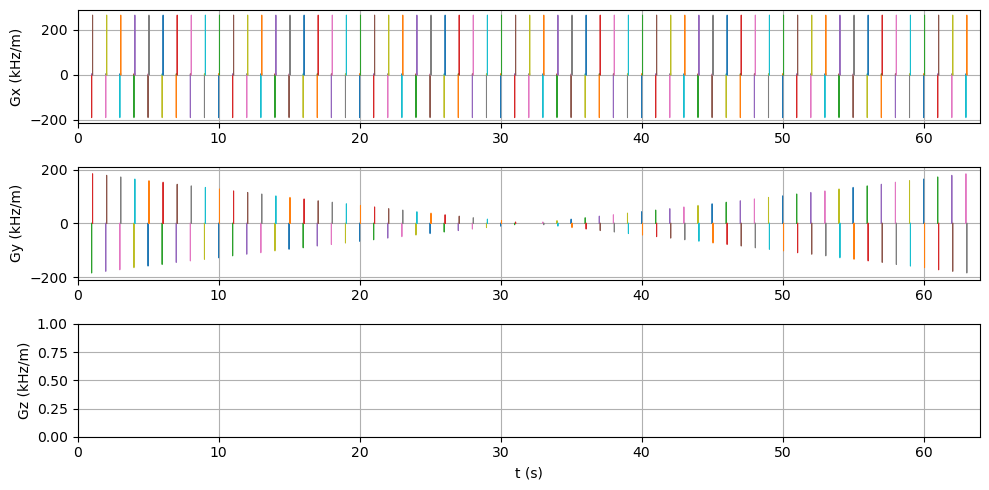

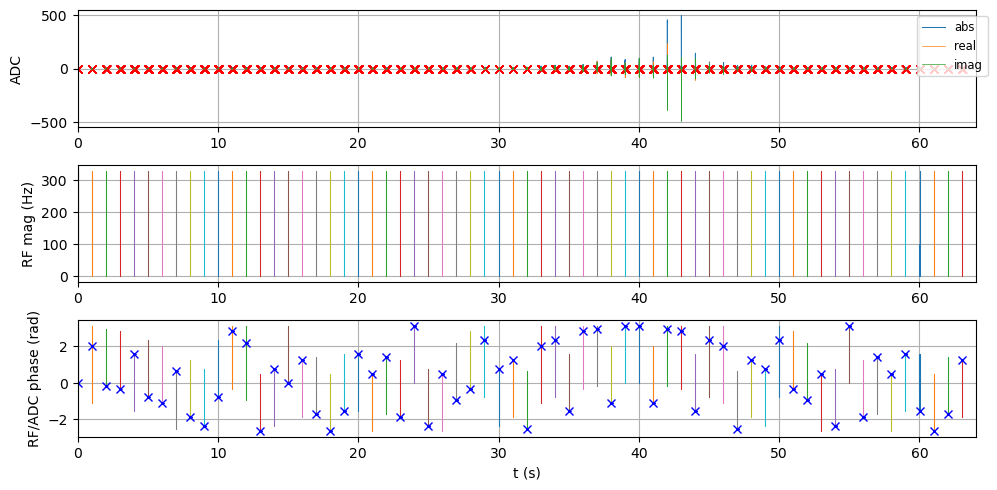

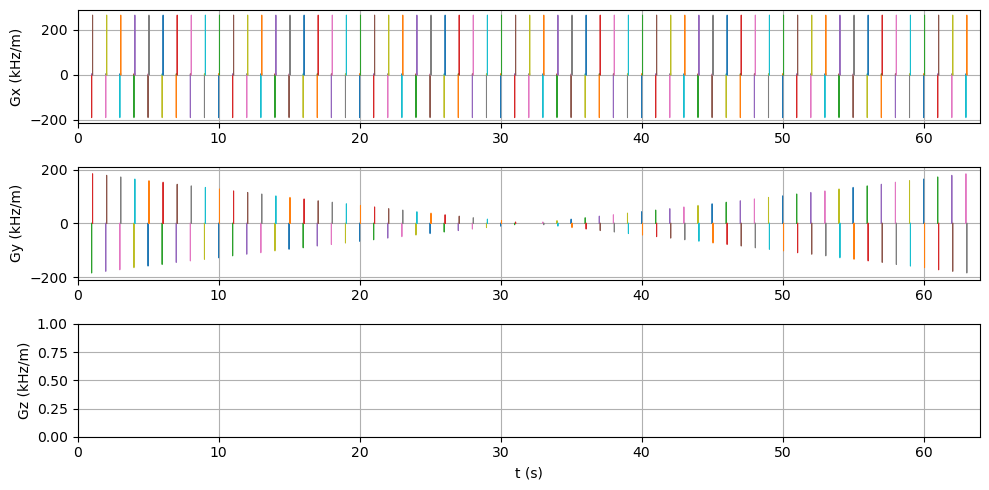

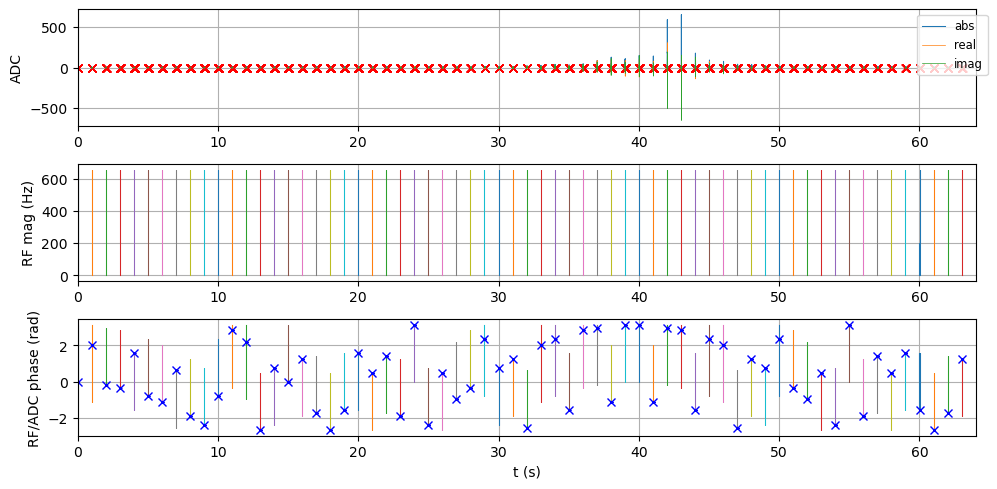

In [10]:
# Define parameters as plain variables
experiment_id = 'FLASH_2D'
fov = (200e-3, 200e-3, 8e-3)
Nread = 64
Nphase = 64
TR = 1.0
FA = torch.tensor(30 * np.pi / 180)
FA2 = torch.tensor(60 * np.pi / 180)

# Generate sequence using standard parameters
seq = seq_FLASH(
    fov=fov,
    Nread=Nread,
    Nphase=Nphase,
    FA=FA,
    bw=1000,
    TR=TR,
    experiment_id=experiment_id
)

# Get variables from sequence definitions (set inside the function)
permvec = seq.get_definition('permvec')


#quick 2D brain phantom sim with small changes
obj=mr0.util.load_phantom([128,128],B0_polynomial=(0,0,-150,1,1,0))  # will download the standard brain phantom and augment it with B0 inhom.
signal, ktraj_adc = mr0.util.simulate(seq,obj,accuracy=1e-5)

# Double FA
seq2 = seq_FLASH(
    fov=fov,
    Nread=Nread,
    Nphase=Nphase,
    FA=FA2,
    bw=1000,
    TR=1.0,
    experiment_id='FLASH_2FA'
)

signal2, ktraj_adc2 = mr0.util.simulate(seq2,obj,accuracy=1e-5)

seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq=seq, signal =signal.numpy())
plt.show()

seq2.plot(plot_now=False)
mr0.util.insert_signal_plot(seq=seq2, signal =signal2.numpy())
plt.show()


zoom into one TR


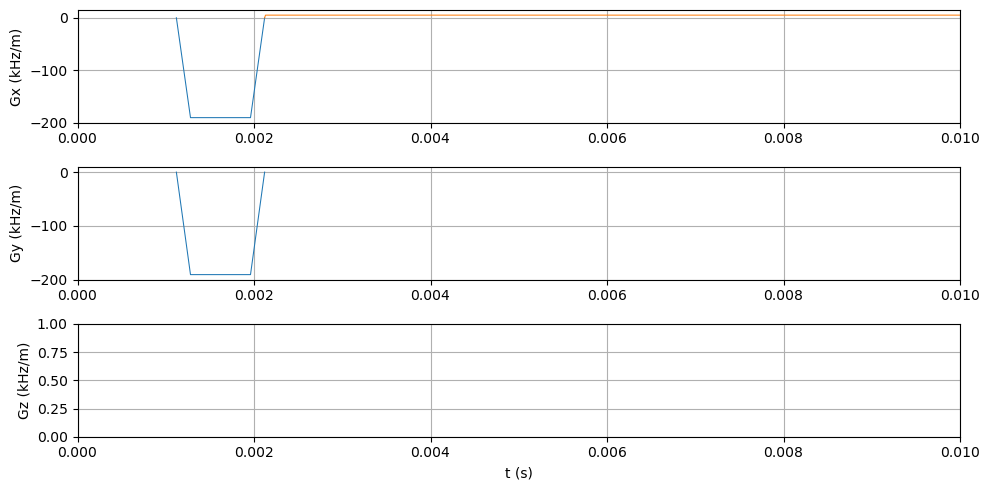

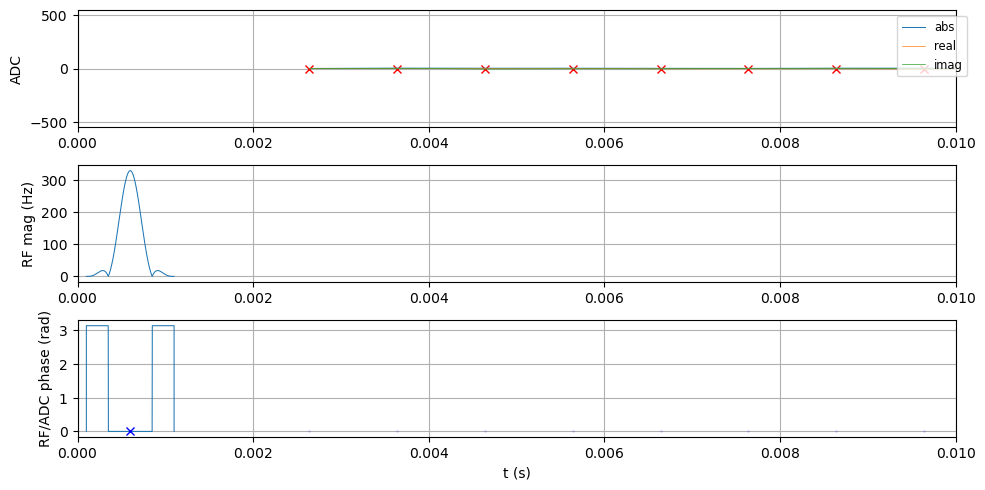

In [11]:

#zoom into one TR
print('zoom into one TR')
seq.plot(plot_now=False,time_range=(0,0.01))
mr0.util.insert_signal_plot(seq=seq, signal =signal.numpy())
plt.show()


/tmp/ipykernel_424612/3428528886.py:49: RuntimeWarning: invalid value encountered in arccos
  mr0.util.imshow(np.acos(np.abs(space.numpy()) / np.abs(space2.numpy())))


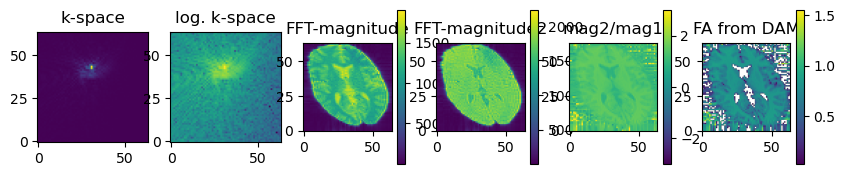

In [12]:
# %% S6: MR IMAGE RECON of signal ::: #####################################
fig = plt.figure(figsize=(10,2))  # fig.clf()

kspace = torch.reshape((signal), (Nphase, Nread)).clone().t()
ipermvec = np.argsort(permvec)
kspace=kspace[:,ipermvec]

# fftshift FFT fftshift
spectrum = torch.fft.fftshift(kspace)
space = torch.fft.fft2(spectrum)
space = torch.fft.ifftshift(space)


kspace2 = torch.reshape((signal2), (Nphase, Nread)).clone().t()
kspace2=kspace2[:,ipermvec]

# fftshift FFT fftshift
spectrum2 = torch.fft.fftshift(kspace2)
space2 = torch.fft.fft2(spectrum2)
space2 = torch.fft.ifftshift(space2)


plt.subplot(161)
plt.title('k-space')
mr0.util.imshow(np.abs(kspace.numpy()))
plt.subplot(162)
plt.title('log. k-space')
mr0.util.imshow(np.log(np.abs(kspace.numpy())))

plt.subplot(163)
plt.title('FFT-magnitude')
mr0.util.imshow(np.abs(space.numpy()))
plt.colorbar()

plt.subplot(164)
plt.title('FFT-magnitude2')
mr0.util.imshow(np.abs(space2.numpy()))
plt.colorbar()

plt.subplot(165)
plt.title('mag2/mag1')
mr0.util.imshow(np.abs(space2.numpy()) / np.abs(space.numpy()))
plt.clim(-3,+3)
plt.colorbar()

plt.subplot(166)
plt.title('FA from DAM')
#https://qmrlab.org/mooc/b1-mapping/
mr0.util.imshow(np.acos(np.abs(space.numpy()) / np.abs(space2.numpy())))
plt.colorbar()



In [13]:
# %% S3. CHECK, PLOT and WRITE the sequence  as .seq
# Check whether the timing of the sequence is correct
ok, error_report = seq.check_timing()
if ok:
    print('Timing check passed successfully')
else:
    print('Timing check failed. Error listing follows:')
    [print(e) for e in error_report]

Timing check passed successfully


# Phantom changes

If you alter phantom parameters between

```
obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
obj_p = obj_p.interpolate(sz[0], sz[1], 1)
```
and
```
obj_p = obj_p.build()
```

you can alter the object manually to study the effects to the simulation.

E.g. we can increase the B0 inhomogeneity and see efects in phase images or observe distortions.
```
dB0_factor=10
obj_p.B0 *= dB0_factor    # alter the B0 inhomogeneity
```

VoxelGridPhantom
size = tensor([0.2000, 0.2000, 0.0080])


/home/ctr28/miniconda3/envs/ctr28_b1map/lib/python3.13/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


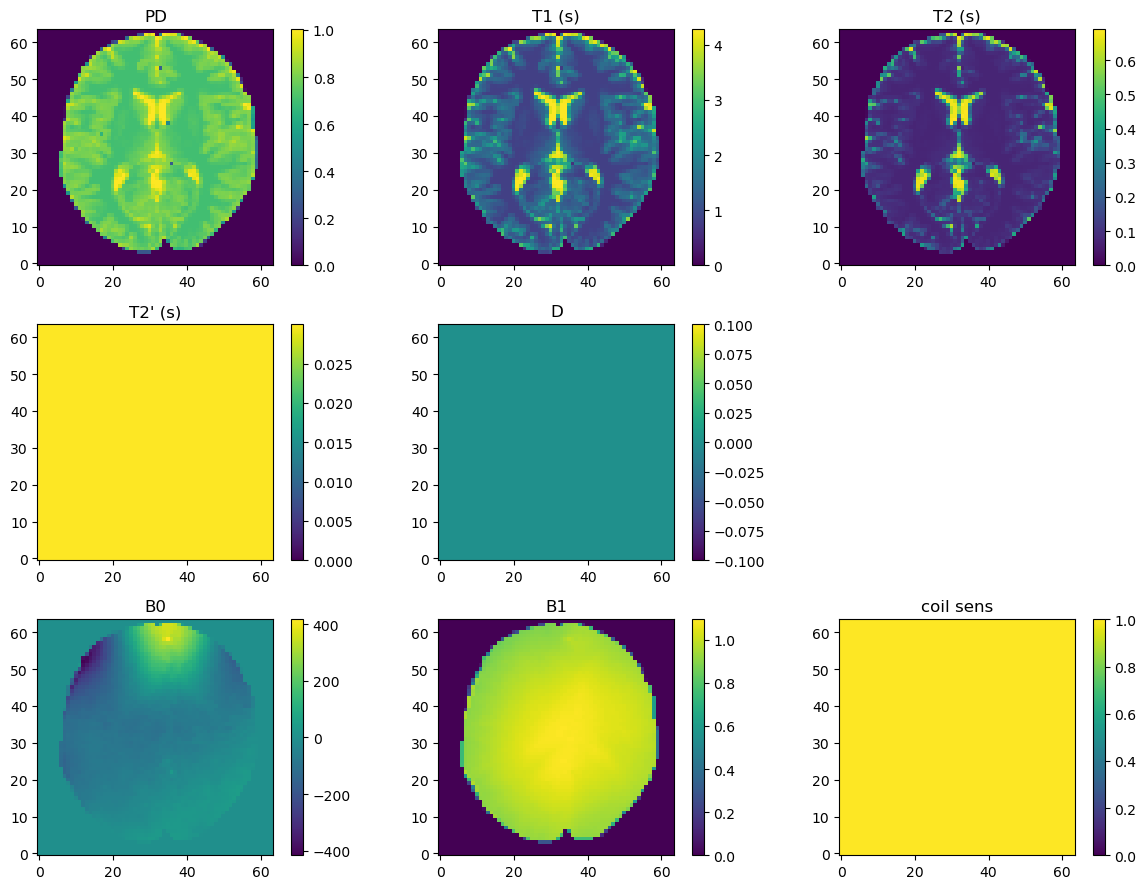

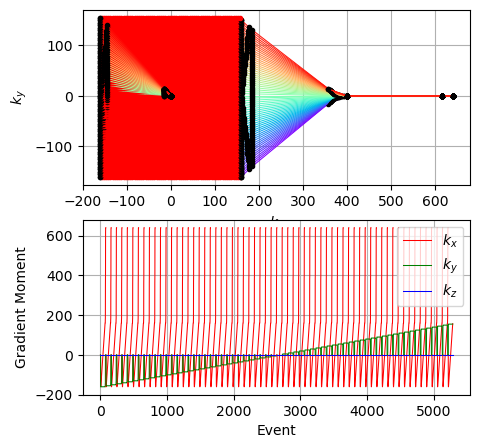

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000954156 s
Compute Graph
Computing Graph: 0.000280364 s
Analyze Graph
Analyzing Graph: 0.000002389 s
Converting Rust -> Python: 0.000059482 s
<<<< Rust <<<<


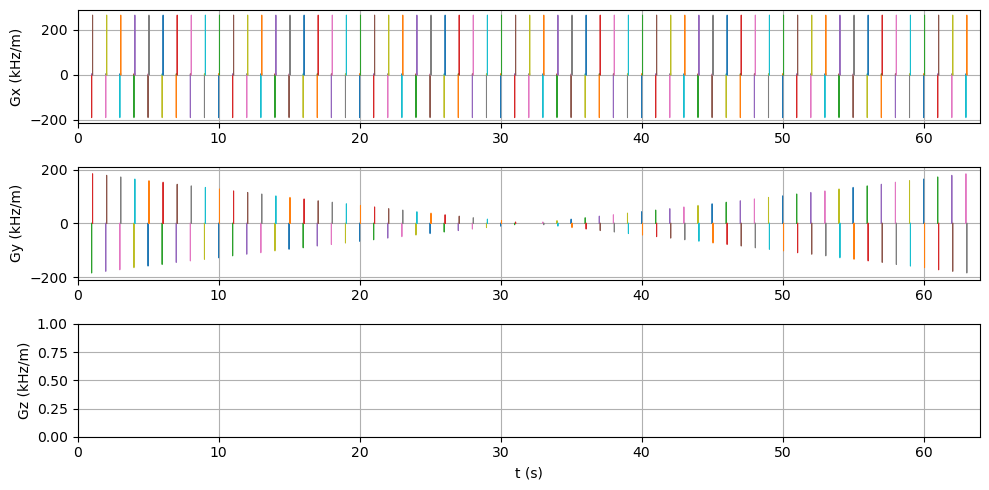

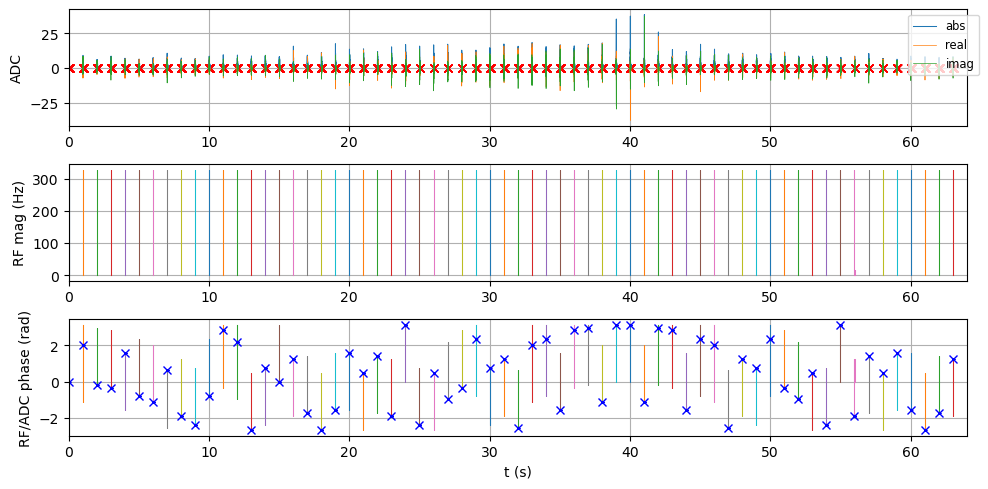

/tmp/ipykernel_424612/3883556977.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  signal += 1e-4 * np.random.randn(signal.shape[0], 2).view(np.complex128)


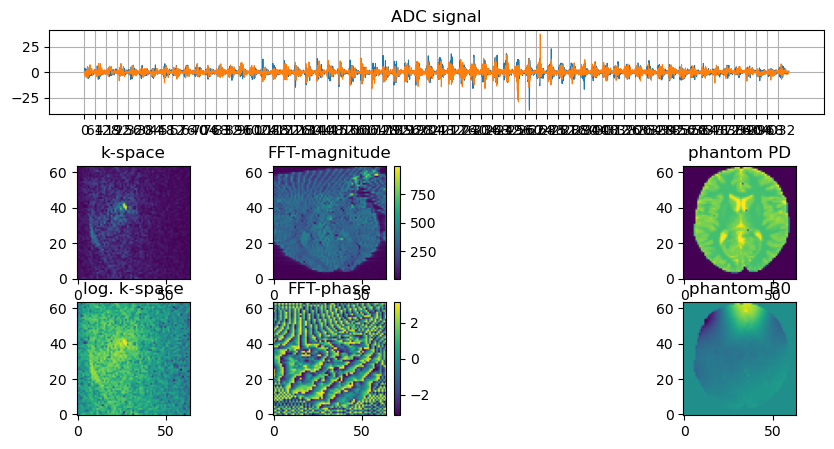

In [14]:
# @title export, and manual phantom definition and reconstruction

# Prepare the sequence output for the scanner
# Note: Definitions and file writing are already handled in the seq_FLASH function

dB0_factor=10 # @param {type: "slider", min: 1, max: 10}

# %% S4: SETUP SPIN SYSTEM/object on which we can run the MR sequence external.seq from above
sz = [64, 64]
# (i) load a phantom object from file
obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
obj_p = obj_p.interpolate(sz[0], sz[1], 1)
# Manipulate loaded data
obj_p.T2dash[:] = 30e-3
obj_p.D *= 0
obj_p.B0 *= dB0_factor    # alter the B0 inhomogeneity
# Store PD and B0 for comparison
PD = obj_p.PD
B0 = obj_p.B0
obj_p.plot()
# Convert Phantom into simulation data
obj_p = obj_p.build()


# %% S5:. SIMULATE  the external.seq file and add acquired signal to ADC plot
# Read in the sequence
seq.write(experiment_id + '.seq')
seq0 = mr0.Sequence.import_file(experiment_id + '.seq')
seq0.plot_kspace_trajectory()
# Simulate the sequence
graph = mr0.compute_graph(seq0, obj_p, 200, 1e-3)
signal = mr0.execute_graph(graph, seq0, obj_p, print_progress=False)

# PLOT sequence with signal in the ADC subplot
seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq=seq, signal =signal.numpy())
plt.show()


# additional noise as simulation is perfect
signal += 1e-4 * np.random.randn(signal.shape[0], 2).view(np.complex128)


# %% S6: MR IMAGE RECON of signal ::: #####################################
fig = plt.figure()  # fig.clf()
plt.subplot(411)
plt.title('ADC signal')
kspace = torch.reshape((signal), (Nphase, Nread)).clone().t()
plt.plot(torch.real(signal), label='real')
plt.plot(torch.imag(signal), label='imag')

ipermvec = np.argsort(permvec)

kspace=kspace[:,ipermvec]
# this adds ticks at the correct position szread
major_ticks = np.arange(0, Nphase * Nread, Nread)
ax = plt.gca()
ax.set_xticks(major_ticks)
ax.grid()

# fftshift FFT fftshift
spectrum = torch.fft.fftshift(kspace)
space = torch.fft.fft2(spectrum)
space = torch.fft.ifftshift(space)

plt.subplot(345)
plt.title('k-space')
mr0.util.imshow(np.abs(kspace.numpy()))
plt.subplot(349)
plt.title('log. k-space')
mr0.util.imshow(np.log(np.abs(kspace.numpy())))

plt.subplot(346)
plt.title('FFT-magnitude')
mr0.util.imshow(np.abs(space.numpy()))
plt.colorbar()
plt.subplot(3, 4, 10)
plt.title('FFT-phase')
mr0.util.imshow(np.angle(space.numpy()), vmin=-np.pi, vmax=np.pi)
plt.colorbar()

# % compare with original phantom obj_p.PD
plt.subplot(348)
plt.title('phantom PD')
mr0.util.imshow(PD)
plt.subplot(3, 4, 12)
plt.title('phantom B0')
mr0.util.imshow(B0)

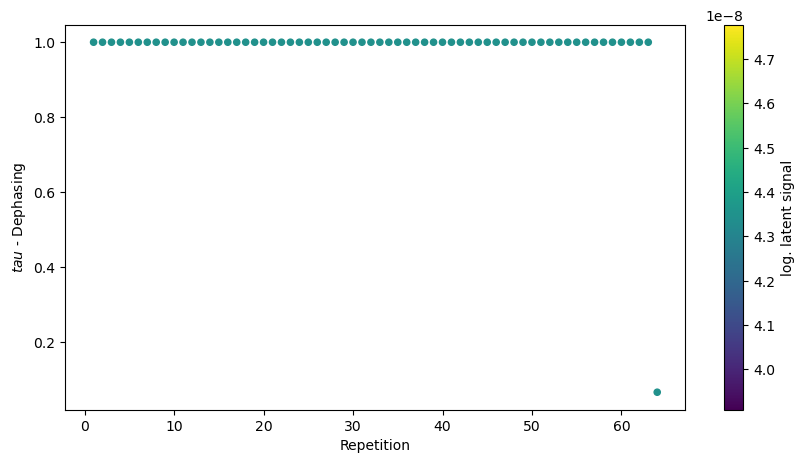

In [15]:
#@title Plot the Phase Distribution Graph

plt.figure()
graph.plot(dephasing="tau", color="latent signal")
plt.show()